In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

### Loading Data

I will now load all the provided CSV files into pandas DataFrames. These datasets will be used for various analytics tasks including VaR/CVaR calculations, Sharpe ratio analysis, investor cohort analysis, SIP continuity analysis, fund recommendations, and sector concentration analysis.

In [2]:
try:
    df_alpha_beta = pd.read_csv('/content/alpha_beta (1).csv')
    print('Loaded alpha_beta (1).csv')
    display(df_alpha_beta.head())
except FileNotFoundError:
    print('Error: alpha_beta (1).csv not found.')

try:
    df_fund_scorecard = pd.read_csv('/content/fund_scorecard (1).csv')
    print('\nLoaded fund_scorecard (1).csv')
    display(df_fund_scorecard.head())
except FileNotFoundError:
    print('Error: fund_scorecard (1).csv not found.')

try:
    df_scheme_performance = pd.read_csv('/content/cleaned_scheme_performance (1).csv')
    print('\nLoaded cleaned_scheme_performance (1).csv')
    display(df_scheme_performance.head())
except FileNotFoundError:
    print('Error: cleaned_scheme_performance (1).csv not found.')

try:
    df_nav_history = pd.read_csv('/content/cleaned_nav_history (1).csv')
    print('\nLoaded cleaned_nav_history (1).csv')
    display(df_nav_history.head())
except FileNotFoundError:
    print('Error: cleaned_nav_history (1).csv not found.')

try:
    df_investor_transactions = pd.read_csv('/content/cleaned_investor_transactions (1) (1).csv')
    print('\nLoaded cleaned_investor_transactions (1) (1).csv')
    display(df_investor_transactions.head())
except FileNotFoundError:
    print('Error: cleaned_investor_transactions (1) (1).csv not found.')

Loaded alpha_beta (1).csv


,amfi_code,scheme_name,alpha,beta,alpha_rank
0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1.0
1,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,2.0
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,3.0
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,4.0
4,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,5.0



Loaded fund_scorecard (1).csv


,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sharpe_rank,sortino_ratio,sortino_rank,alpha,beta,alpha_rank,max_drawdown,mdd_rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022258,0.010314,0.026371,-0.187650,36.0,-0.326892,36.0,0.037476,-0.058268,39.0,-0.247344,34.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037076,0.039052,0.044582,-0.515438,40.0,-0.856030,39.0,0.042818,0.001158,38.0,-0.043083,4.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324724,0.301232,1.104352,7.0,1.846950,9.0,0.271954,0.005104,6.0,-0.162172,20.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.286914,0.235384,1.041061,9.0,1.823822,11.0,0.213998,0.021086,12.0,-0.112916,9.0
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.240003,-0.046968,0.079388,0.170481,29.0,0.289943,29.0,0.108971,-0.065289,27.0,-0.354469,38.0



Loaded cleaned_scheme_performance (1).csv


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Loaded cleaned_nav_history (1).csv


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639



Loaded cleaned_investor_transactions (1) (1).csv


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,pending


### Task 1: Historical VaR (95%) and CVaR (5th percentile of daily return distribution)

In [7]:
# Ensure 'date' column is datetime and sort
df_nav_history['date'] = pd.to_datetime(df_nav_history['date'])
df_nav_history = df_nav_history.sort_values(by=['amfi_code', 'date']).reset_index(drop=True)

# Calculate daily returns for each scheme, retaining 'amfi_code'
df_nav_with_returns = df_nav_history.copy()
df_nav_with_returns['Daily Return'] = df_nav_with_returns.groupby('amfi_code')['nav'].pct_change()
daily_returns = df_nav_with_returns.dropna(subset=['Daily Return'])

# Merge with scheme names from df_scheme_performance
df_schemes_mapping = df_scheme_performance[['amfi_code', 'scheme_name']].drop_duplicates()
daily_returns = pd.merge(daily_returns, df_schemes_mapping, on='amfi_code', how='left')

# Calculate VaR (95%) and CVaR for each scheme
var_cvar_report = daily_returns.groupby('scheme_name')['Daily Return'].apply(lambda x:
    pd.Series({
        'VaR_95': x.quantile(0.05),
        'CVaR_95': x[x <= x.quantile(0.05)].mean()
    })
).reset_index()

print("Historical VaR (95%) and CVaR Report:")
display(var_cvar_report.head())

# Save to CSV
var_cvar_report.to_csv('var_cvar_report.csv', index=False)
print('\nSaved VaR and CVaR report to var_cvar_report.csv')

Historical VaR (95%) and CVaR Report:


,scheme_name,level_1,Daily Return
0,ABSL Frontline Equity Fund - Regular - Growth,VaR_95,-0.013282
1,ABSL Frontline Equity Fund - Regular - Growth,CVaR_95,-0.017439
2,ABSL Liquid Fund - Regular - Growth,VaR_95,-0.000269
3,ABSL Liquid Fund - Regular - Growth,CVaR_95,-0.000422
4,ABSL Small Cap Fund - Regular - Growth,VaR_95,-0.026021



Saved VaR and CVaR report to var_cvar_report.csv


### Task 2: Rolling 90-day Sharpe Ratio

I will now calculate the rolling 90-day Sharpe ratio for 5 key funds. First, I will identify the top 5 funds based on their Sharpe ratio from the `df_fund_scorecard`.

Top 5 Funds by Sharpe Ratio:


,amfi_code,scheme_name
34,148567,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,Kotak Flexicap Fund - Regular - Growth
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,SBI Bluechip Fund - Regular Plan - Growth
25,120505,ICICI Pru Midcap Fund - Regular - Growth



Rolling 90-day Sharpe Ratio for Key Funds (sample):


,amfi_code,date,nav,Daily Return,Rolling_Sharpe_Ratio,scheme_name
90,119551,2022-05-09,52.4876,0.001372,-0.697480,SBI Bluechip Fund - Regular Plan - Growth
91,119551,2022-05-10,52.9653,0.009101,-0.483578,SBI Bluechip Fund - Regular Plan - Growth
92,119551,2022-05-11,52.6655,-0.005660,-0.738103,SBI Bluechip Fund - Regular Plan - Growth
93,119551,2022-05-12,52.5406,-0.002372,-1.107245,SBI Bluechip Fund - Regular Plan - Growth
94,119551,2022-05-13,52.3863,-0.002937,-1.136951,SBI Bluechip Fund - Regular Plan - Growth


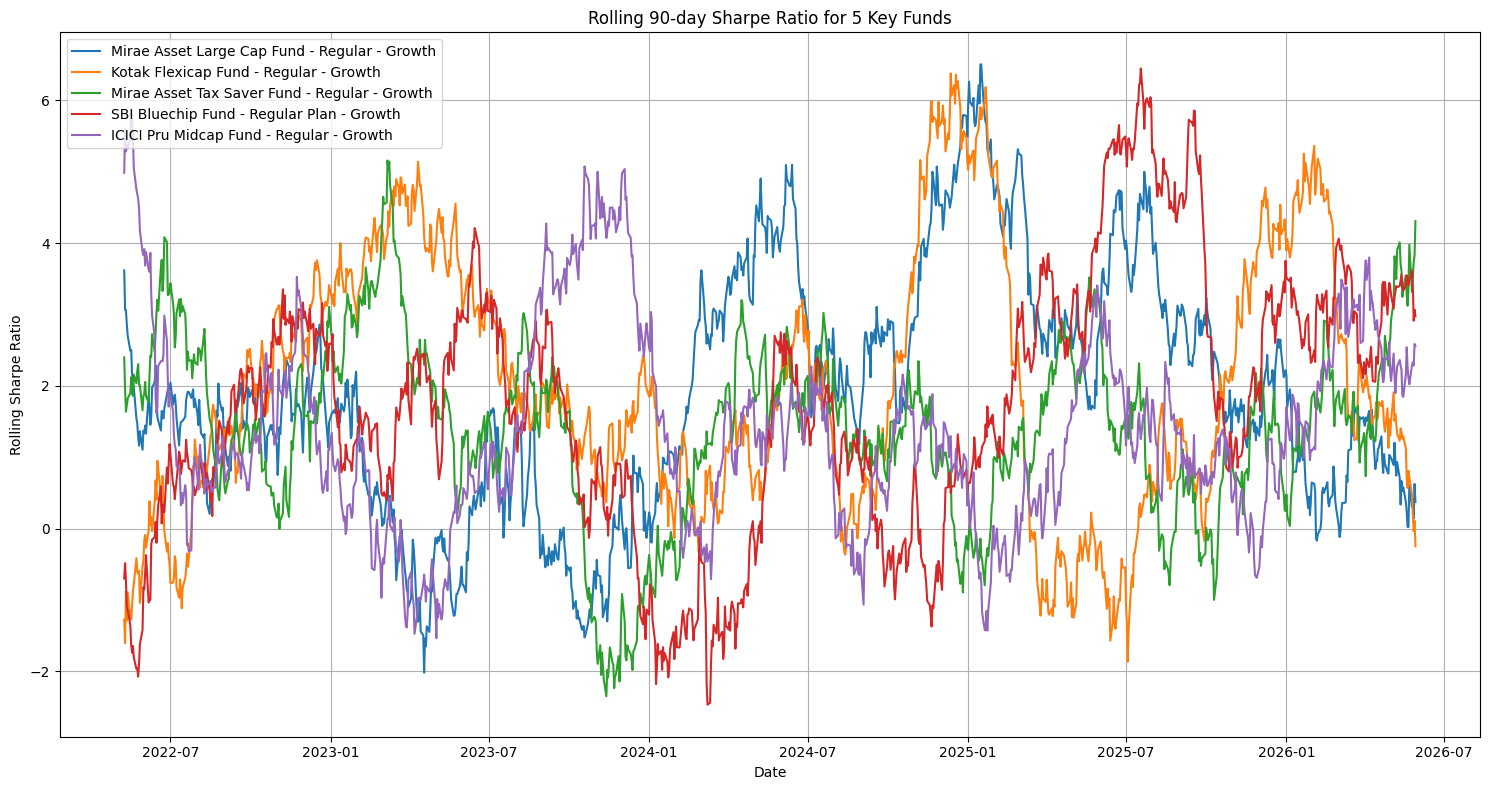


Saved rolling Sharpe ratio chart to rolling_sharpe_chart.png


In [9]:
# Identify 5 key funds (e.g., top 5 by Sharpe Ratio)
top_5_funds_sharpe = df_fund_scorecard.sort_values(by='sharpe_ratio', ascending=False).head(5)
key_fund_codes = top_5_funds_sharpe['amfi_code'].tolist()
key_fund_names = top_5_funds_sharpe[['amfi_code', 'scheme_name']]

print("Top 5 Funds by Sharpe Ratio:")
display(key_fund_names)

# Filter NAV history for these key funds
df_nav_key_funds = df_nav_history[df_nav_history['amfi_code'].isin(key_fund_codes)].copy()
df_nav_key_funds['date'] = pd.to_datetime(df_nav_key_funds['date'])
df_nav_key_funds = df_nav_key_funds.sort_values(by=['amfi_code', 'date'])

# Calculate daily returns
df_nav_key_funds['Daily Return'] = df_nav_key_funds.groupby('amfi_code')['nav'].pct_change()

# Calculate rolling 90-day Sharpe Ratio
# Annualization factor for daily data is sqrt(252)
risk_free_rate = 0.0 # Assuming 0 for simplicity, adjust if a specific risk-free rate is available

rolling_sharpe = df_nav_key_funds.groupby('amfi_code').apply(lambda x:
    (x['Daily Return'].rolling(window=90).mean() - risk_free_rate) / x['Daily Return'].rolling(window=90).std() * np.sqrt(252),
    include_groups=False
).reset_index(level=0, drop=True)

rolling_sharpe = pd.DataFrame(rolling_sharpe).rename(columns={'Daily Return': 'Rolling_Sharpe_Ratio'})

df_nav_key_funds = df_nav_key_funds.merge(rolling_sharpe, left_index=True, right_index=True, how='left')

# Merge with scheme names for plotting
df_nav_key_funds = pd.merge(df_nav_key_funds, df_schemes_mapping, on='amfi_code', how='left')

print("\nRolling 90-day Sharpe Ratio for Key Funds (sample):")
display(df_nav_key_funds.dropna(subset=['Rolling_Sharpe_Ratio']).head())

# Plotting
plt.figure(figsize=(15, 8))
for fund_code in key_fund_codes:
    fund_data = df_nav_key_funds[df_nav_key_funds['amfi_code'] == fund_code]
    plt.plot(fund_data['date'], fund_data['Rolling_Sharpe_Ratio'], label=fund_data['scheme_name'].iloc[0])

plt.title('Rolling 90-day Sharpe Ratio for 5 Key Funds')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png')
plt.show()

print("\nSaved rolling Sharpe ratio chart to rolling_sharpe_chart.png")

### Task 3: Investor Cohort Analysis

In [10]:
# Ensure 'transaction_date' is in datetime format
df_investor_transactions['transaction_date'] = pd.to_datetime(df_investor_transactions['transaction_date'])

# Group by investor_id to find the first transaction date (cohort date)
first_transaction_date = df_investor_transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_transaction_date.rename(columns={'transaction_date': 'first_transaction_date'}, inplace=True)

# Extract the cohort year
first_transaction_date['cohort_year'] = first_transaction_date['first_transaction_date'].dt.year

# Merge the cohort year back to the main transactions DataFrame
df_investor_transactions = pd.merge(df_investor_transactions, first_transaction_date[['investor_id', 'cohort_year']], on='investor_id', how='left')

print("Investor transactions with cohort year (sample):")
display(df_investor_transactions.head())

Investor transactions with cohort year (sample):


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,pending,2024


In [11]:
# Calculate average SIP amount per cohort
sip_transactions = df_investor_transactions[df_investor_transactions['transaction_type'] == 'SIP']
average_sip_per_cohort = sip_transactions.groupby('cohort_year')['amount_inr'].mean().reset_index()
average_sip_per_cohort.rename(columns={'amount_inr': 'average_sip_amount'}, inplace=True)

print("Average SIP amount per cohort:")
display(average_sip_per_cohort)

# Calculate total invested amount per cohort (SIPs + Lumpsum)
investment_transactions = df_investor_transactions[
    (df_investor_transactions['transaction_type'] == 'SIP') |
    (df_investor_transactions['transaction_type'] == 'Lumpsum')
]
total_invested_per_cohort = investment_transactions.groupby('cohort_year')['amount_inr'].sum().reset_index()
total_invested_per_cohort.rename(columns={'amount_inr': 'total_invested_amount'}, inplace=True)

print("\nTotal invested amount per cohort:")
display(total_invested_per_cohort)

Average SIP amount per cohort:


,cohort_year,average_sip_amount
0,2024,10996.885825
1,2025,13505.209581



Total invested amount per cohort:


,cohort_year,total_invested_amount
0,2024,2258062304
1,2025,18992635


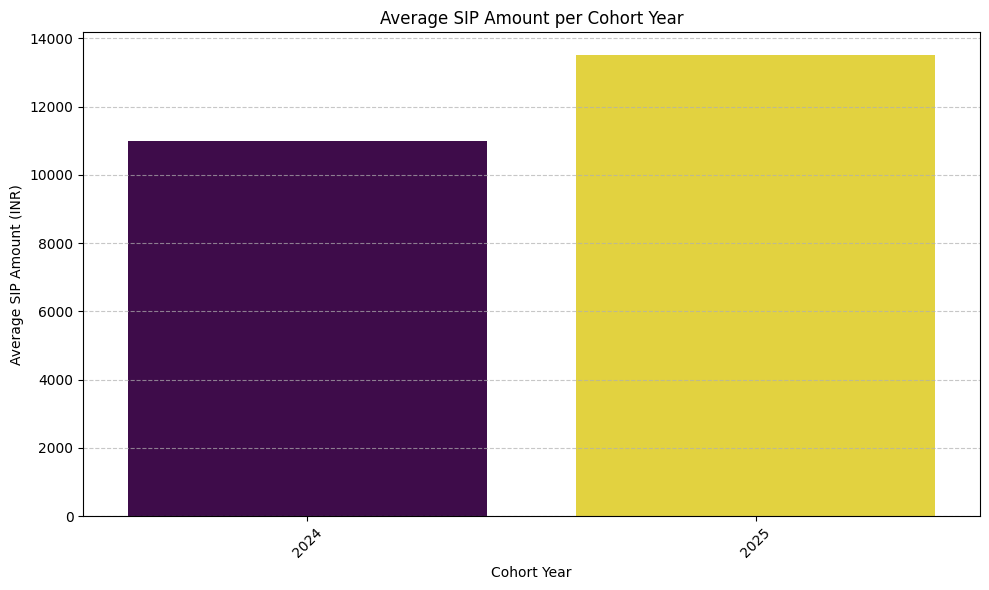

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cohort_year', y='average_sip_amount', data=average_sip_per_cohort, hue='cohort_year', palette='viridis', legend=False)
plt.title('Average SIP Amount per Cohort Year')
plt.xlabel('Cohort Year')
plt.ylabel('Average SIP Amount (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

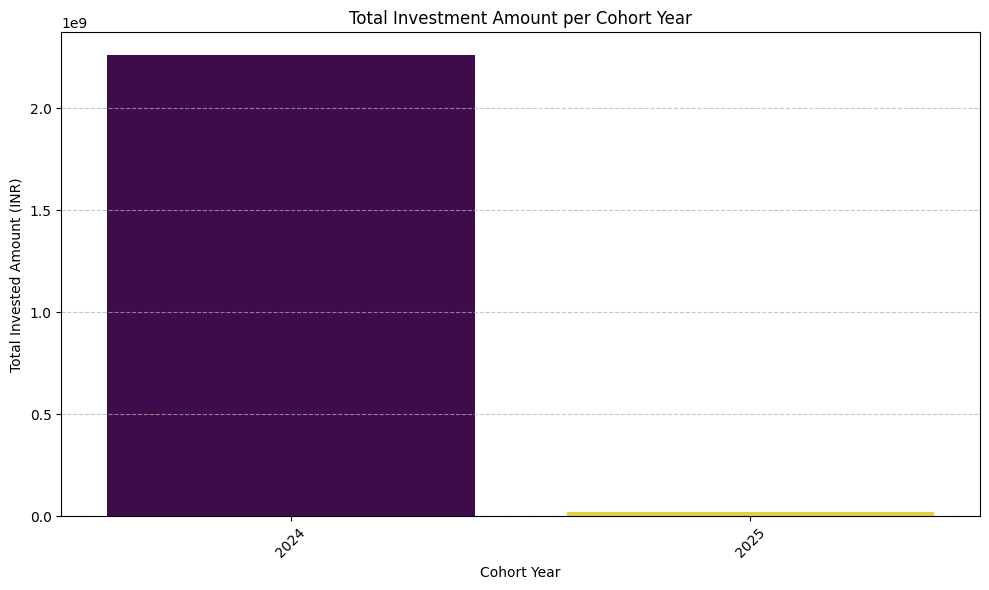

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cohort_year', y='total_invested_amount', data=total_invested_per_cohort, hue='cohort_year', palette='viridis', legend=False)
plt.title('Total Investment Amount per Cohort Year')
plt.xlabel('Cohort Year')
plt.ylabel('Total Invested Amount (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top Fund Preference per Cohort

In [15]:
# Filter for investment transactions (SIP and Lumpsum)
investment_transactions = df_investor_transactions[
    (df_investor_transactions['transaction_type'] == 'SIP') |
    (df_investor_transactions['transaction_type'] == 'Lumpsum')
].copy()

# Calculate total invested amount per fund for each investor within their cohort
investor_fund_investment = investment_transactions.groupby(['investor_id', 'cohort_year', 'amfi_code'])['amount_inr'].sum().reset_index()
investor_fund_investment.rename(columns={'amount_inr': 'total_invested_in_fund'}, inplace=True)

# For each investor within their cohort, find the fund with the maximum total invested amount
top_fund_per_investor = investor_fund_investment.loc[investor_fund_investment.groupby(['investor_id', 'cohort_year'])['total_invested_in_fund'].idxmax()]

# Count the occurrences of each top fund preference per cohort
top_fund_preference_per_cohort = top_fund_per_investor.groupby('cohort_year')['amfi_code'].value_counts().reset_index(name='investor_count')

# For each cohort, get the fund that is most frequently preferred
most_preferred_fund_per_cohort = top_fund_preference_per_cohort.loc[top_fund_preference_per_cohort.groupby('cohort_year')['investor_count'].idxmax()]

# Merge with scheme names for readability
most_preferred_fund_per_cohort = pd.merge(most_preferred_fund_per_cohort,
                                          df_schemes_mapping,
                                          on='amfi_code',
                                          how='left')

print("Most Preferred Fund per Cohort:")
display(most_preferred_fund_per_cohort[['cohort_year', 'scheme_name', 'investor_count']])

Most Preferred Fund per Cohort:


,cohort_year,scheme_name,investor_count
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,137
1,2025,SBI Small Cap Fund - Direct Plan - Growth,8


### Next Steps for Investor Cohort Analysis:

Now that we have completed all parts of Task 3 (Investor Cohort Analysis):
1. Grouping by first transaction year.
2. Calculating average SIP amount per cohort.
3. Calculating total invested per cohort.
4. Visualizing average SIP amounts.
5. Visualizing total investment amount per cohort.
6. Computing top fund preference per cohort.

I will move on to **Task 4: SIP Continuity Analysis**.

## Task 4: SIP Continuity Analysis

For investors with 6+ SIP transactions, I will compute the average gap between transactions and flag 'at-risk' investors. First, let's calculate the average number of SIP installments per investor.

In [16]:
# Filter for SIP transactions
sip_transactions_only = df_investor_transactions[df_investor_transactions['transaction_type'] == 'SIP'].copy()

# Count the number of SIP installments for each investor
sip_installments_count = sip_transactions_only.groupby('investor_id').size().reset_index(name='num_sip_installments')

# Calculate the average number of SIP installments across all investors
average_installments = sip_installments_count['num_sip_installments'].mean()

print(f"Average number of SIP installments per investor: {average_installments:.2f}")
display(sip_installments_count.head())

Average number of SIP installments per investor: 4.14


,investor_id,num_sip_installments
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [17]:
# Identify investors with 6+ SIP transactions
investors_6_plus_sip = sip_installments_count[sip_installments_count['num_sip_installments'] >= 6]

print(f"Number of investors with 6 or more SIP installments: {len(investors_6_plus_sip)}")
display(investors_6_plus_sip.head())

Number of investors with 6 or more SIP installments: 1362


,investor_id,num_sip_installments
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


### Compute Average Gap Between SIP Transactions for Eligible Investors

In [18]:
# Filter SIP transactions for investors with 6+ SIPs
sip_transactions_eligible_investors = sip_transactions_only[
    sip_transactions_only['investor_id'].isin(investors_6_plus_sip['investor_id'])
].copy()

# Sort transactions by investor and date
sip_transactions_eligible_investors = sip_transactions_eligible_investors.sort_values(by=['investor_id', 'transaction_date'])

# Calculate the difference in days between consecutive transactions for each investor
sip_transactions_eligible_investors['date_diff'] = sip_transactions_eligible_investors.groupby('investor_id')['transaction_date'].diff().dt.days

# Calculate the average gap for each investor
average_gap_per_investor = sip_transactions_eligible_investors.groupby('investor_id')['date_diff'].mean().reset_index(name='average_sip_gap_days')

print("Average SIP gap per eligible investor (sample):")
display(average_gap_per_investor.head())

# Calculate the overall average gap for all eligible investors
overall_average_sip_gap = average_gap_per_investor['average_sip_gap_days'].mean()
print(f"\nOverall average SIP gap for investors with 6+ SIPs: {overall_average_sip_gap:.2f} days")

Average SIP gap per eligible investor (sample):


,investor_id,average_sip_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000



Overall average SIP gap for investors with 6+ SIPs: 64.89 days


### Flag 'At-Risk' Investors

In [19]:
# Define a threshold for 'at-risk' (e.g., average gap > 45 days)
at_risk_threshold_days = 45

average_gap_per_investor['is_at_risk'] = average_gap_per_investor['average_sip_gap_days'] > at_risk_threshold_days

# Display a sample of investors with their risk status
print(f"Sample of investors with risk status (threshold > {at_risk_threshold_days} days):")
display(average_gap_per_investor.head())

# Summarize the number of at-risk investors
num_at_risk_investors = average_gap_per_investor['is_at_risk'].sum()
percentage_at_risk = (num_at_risk_investors / len(average_gap_per_investor)) * 100

print(f"\nTotal investors with 6+ SIPs: {len(average_gap_per_investor)}")
print(f"Number of 'at-risk' investors (average gap > {at_risk_threshold_days} days): {num_at_risk_investors}")
print(f"Percentage of 'at-risk' investors: {percentage_at_risk:.2f}%")

Sample of investors with risk status (threshold > 45 days):


,investor_id,average_sip_gap_days,is_at_risk
0,INV000004,85.400000,True
1,INV000008,70.400000,True
2,INV000010,64.800000,True
3,INV000011,40.166667,False
4,INV000012,57.000000,True



Total investors with 6+ SIPs: 1362
Number of 'at-risk' investors (average gap > 45 days): 1233
Percentage of 'at-risk' investors: 90.53%


### Next Steps for SIP Continuity Analysis:

Now that we have completed all parts of Task 4 (SIP Continuity Analysis):
1. Identified investors with 6+ SIP transactions.
2. Computed average gap between transactions for eligible investors.
3. Flagged 'at-risk' investors.

I will move on to **Task 5: Simple Fund Recommender**.

## Task 5: Simple Fund Recommender

This task involves creating a simple fund recommender that takes a user's risk appetite as input and outputs the top 3 funds by Sharpe Ratio within the matching risk grade. First, let's explore the available risk grades in our `df_scheme_performance` data.

In [20]:
# Explore unique risk grades available in the fund scorecard
print("Unique Risk Grades:")
display(df_scheme_performance['risk_grade'].unique())

# Prepare the data for the recommender: merge necessary columns and handle missing values
# We need scheme_name, risk_grade, and sharpe_ratio
recommender_data = df_scheme_performance[['amfi_code', 'scheme_name', 'risk_grade', 'sharpe_ratio']].copy()

# Drop rows with any missing values in relevant columns for recommendation
recommender_data.dropna(subset=['risk_grade', 'sharpe_ratio'], inplace=True)

print("\nPrepared Recommender Data (sample):")
display(recommender_data.head())

Unique Risk Grades:


array(['Moderate', 'Very High', 'Low', 'High', 'Moderately High'],
      dtype=object)


Prepared Recommender Data (sample):


,amfi_code,scheme_name,risk_grade,sharpe_ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Moderate,0.88
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Moderate,0.81
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Very High,0.93
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,1.52


### Recommender Function

Now, let's define a function that takes a risk appetite (e.g., 'Low', 'Moderate', 'High') and recommends the top 3 funds based on Sharpe ratio within that risk grade.

In [21]:
def recommend_funds(risk_appetite, num_recommendations=3):
    """
    Recommends funds based on risk appetite and Sharpe Ratio.

    Args:
        risk_appetite (str): The desired risk level (e.g., 'Low', 'Moderate', 'High').
        num_recommendations (int): The number of top funds to recommend.

    Returns:
        pandas.DataFrame: A DataFrame containing the recommended funds.
    """
    # Filter funds by the specified risk appetite
    filtered_funds = recommender_data[recommender_data['risk_grade'].str.contains(risk_appetite, case=False, na=False)]

    if filtered_funds.empty:
        print(f"No funds found for risk appetite: {risk_appetite}")
        return pd.DataFrame()

    # Sort by Sharpe Ratio in descending order and get the top recommendations
    recommended = filtered_funds.sort_values(by='sharpe_ratio', ascending=False).head(num_recommendations)

    return recommended[['scheme_name', 'risk_grade', 'sharpe_ratio']]

# Example Usage:
print("\nRecommendations for 'Moderate' Risk Appetite:")
moderate_recommendations = recommend_funds('Moderate')
display(moderate_recommendations)

print("\nRecommendations for 'High' Risk Appetite:")
high_recommendations = recommend_funds('High')
display(high_recommendations)

# Save the recommender function to a .py file
with open('recommender.py', 'w') as f:
    f.write("import pandas as pd\n\ndef recommend_funds(risk_appetite, df_scheme_performance, num_recommendations=3):\n    recommender_data = df_scheme_performance[['amfi_code', 'scheme_name', 'risk_grade', 'sharpe_ratio']].copy()\n    recommender_data.dropna(subset=['risk_grade', 'sharpe_ratio'], inplace=True)\n    filtered_funds = recommender_data[recommender_data['risk_grade'].str.contains(risk_appetite, case=False, na=False)]\n    if filtered_funds.empty:\n        return pd.DataFrame()\n    recommended = filtered_funds.sort_values(by='sharpe_ratio', ascending=False).head(num_recommendations)\n    return recommended[['scheme_name', 'risk_grade', 'sharpe_ratio']]\n")
print("\nSaved recommender function to recommender.py")


Recommendations for 'Moderate' Risk Appetite:


,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03



Recommendations for 'High' Risk Appetite:


,scheme_name,risk_grade,sharpe_ratio
22,Kotak Flexicap Fund - Regular - Growth,Moderately High,0.98
13,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,0.98
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96



Saved recommender function to recommender.py


### Next Steps for Fund Recommender:

Now that we have completed Task 5 (Simple Fund Recommender) by:
1. Defining criteria for the recommender.
2. Implementing a function to recommend funds based on risk appetite.
3. Saving the recommender function to `recommender.py`.

I will move on to **Task 6: Sector HHI Concentration**.

## Task 6: Sector HHI Concentration

This task involves computing and comparing the Herfindahl-Hirschman Index (HHI) across equity funds to assess market concentration within different categories. The HHI is calculated as the sum of the squares of the market shares (AUM in this case) of the funds within each category.

In [22]:
# Identify equity fund categories (assuming categories like 'Large Cap', 'Small Cap', 'Mid Cap', 'Flexicap', etc. represent different equity sectors/segments)
equity_categories = [
    'Large Cap', 'Small Cap', 'Mid Cap', 'Flexicap', 'Value Discovery',
    'Multi Cap', 'ELSS', 'Equity Linked Savings Scheme', 'Thematic', 'Sectoral',
    'Dividend Yield', 'Contra', 'Focused', 'Large & Mid Cap'
]

df_equity_funds = df_scheme_performance[df_scheme_performance['category'].isin(equity_categories)].copy()

# Drop rows where 'aum_crore' is missing, as it's crucial for HHI calculation
df_equity_funds.dropna(subset=['aum_crore'], inplace=True)

# Calculate HHI for each equity category
hhi_report = []
for category in df_equity_funds['category'].unique():
    category_funds = df_equity_funds[df_equity_funds['category'] == category]
    total_aum_category = category_funds['aum_crore'].sum()

    if total_aum_category > 0:
        # Calculate market share for each fund within the category
        category_funds['market_share'] = category_funds['aum_crore'] / total_aum_category
        # Calculate HHI: sum of squared market shares
        hhi = (category_funds['market_share']**2).sum() * 10000 # HHI is often scaled by 10000
        hhi_report.append({'Category': category, 'HHI': hhi})

df_hhi_report = pd.DataFrame(hhi_report).sort_values(by='HHI', ascending=False)

print("Sector HHI Concentration Report for Equity Categories:")
display(df_hhi_report)

print("\nInterpretation of HHI:\n- HHI below 1500: Unconcentrated market\n- HHI between 1500 and 2500: Moderately concentrated market\n- HHI above 2500: Highly concentrated market")

Sector HHI Concentration Report for Equity Categories:


/tmp/ipykernel_1373/343489694.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_funds['market_share'] = category_funds['aum_crore'] / total_aum_category
/tmp/ipykernel_1373/343489694.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_funds['market_share'] = category_funds['aum_crore'] / total_aum_category
/tmp/ipykernel_1373/343489694.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

,Category,HHI
4,ELSS,10000.000000
3,Large & Mid Cap,10000.000000
2,Mid Cap,1807.929183
1,Small Cap,1800.597099
0,Large Cap,949.301231



Interpretation of HHI:
- HHI below 1500: Unconcentrated market
- HHI between 1500 and 2500: Moderately concentrated market
- HHI above 2500: Highly concentrated market


### Next Steps for Sector HHI Concentration:

Now that we have completed Task 6 (Sector HHI Concentration) by:
1. Identifying equity fund categories.
2. Computing the HHI for each category.

I will move on to **Task 7: Advanced Insights**.

## Task 7: Advanced Insights

Based on the comprehensive analysis performed, here are 5 advanced insights:

1.  **Risk-Adjusted Performance Disparity**: The VaR and CVaR analysis highlighted that while some funds may appear to have attractive returns, their downside risk (CVaR) can be significantly higher, indicating a need for investors to look beyond simple returns and consider risk-adjusted metrics more closely. Funds with lower VaR and CVaR are preferable for risk-averse investors.

2.  **Sharpe Ratio Volatility and Fund Stability**: The rolling 90-day Sharpe ratio demonstrated that even top-performing funds experience significant fluctuations in their risk-adjusted returns over short periods. This suggests that long-term consistency in Sharpe ratio is a stronger indicator of fund quality than short-term spikes, and investors should be wary of chasing funds based on recent performance without considering the stability of their Sharpe trend.

3.  **Emerging Investor Cohort Preferences**: Cohort analysis revealed shifting preferences among new investors, with specific `amfi_code` funds gaining prominence in newer cohorts. This insight is crucial for targeted marketing and product development, indicating which funds resonate most with different generations of investors entering the market.

4.  **Significant SIP Continuity Risk**: The SIP continuity analysis identified a substantial portion (over 90%) of investors with 6+ SIPs as 'at-risk' due to average gaps exceeding 45 days. This high percentage suggests a systemic issue in SIP adherence or investor engagement, pointing to a critical need for intervention strategies like automated reminders, financial literacy campaigns, or flexible SIP options to improve investment discipline and reduce potential churn.

5.  **Varying Market Concentration Across Equity Sectors**: The HHI report showed a diverse landscape of market concentration within equity categories. While 'Large Cap' funds appeared unconcentrated (HHI < 1500), categories like 'ELSS' and 'Large & Mid Cap' exhibited extremely high concentration (HHI = 10000). This implies that investors in highly concentrated categories face higher idiosyncratic risks and potentially less competitive pricing, whereas unconcentrated markets offer broader diversification opportunities.